# English to Hindi NMT (Seq2Seq LSTM) — Fast Training Version

This version is rewritten so a full run finishes in roughly **20–30 minutes on a normal laptop CPU** (faster on GPU/Colab).

**What changed vs. the original notebook, and why it was slow:**
- The old notebook trained **twice** — once on the full 20,000-row dataset with a big model (cell that took forever), and then had a second "optimized" section that prepared smaller data but never actually rebuilt the model or called `.fit()` on it. So you were paying the full cost of the slow run either way.
- Dataset size, vocabulary size, embedding size, LSTM units, and batch size were all much larger than needed for a first working model.
- `batch_size=16` on CPU is slow — it means far more weight-update steps per epoch than a larger batch.

This notebook keeps **one** training pipeline, sized to be fast, and only trains **once**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: []


## 1. Load & clean data

Cleaning happens **before** sampling, and we filter out long sentences **before** picking our training subset — this way the subset we keep is exactly the data we'll train on (no wasted work later).

In [2]:
df = pd.read_csv('Dataset_English_Hindi.csv')

# Remove missing values, duplicates, extra spaces, empty strings
df = df.dropna(subset=["English", "Hindi"])
df = df.drop_duplicates()
df["English"] = df["English"].str.strip()
df["Hindi"] = df["Hindi"].str.strip()
df = df[(df["English"] != "") & (df["Hindi"] != "")]
df = df.reset_index(drop=True)

df["English"] = df["English"].str.lower()
df["Hindi"] = df["Hindi"].str.lower()

print("Rows after cleaning:", df.shape)

Rows after cleaning: (127375, 2)


## 2. Speed knobs (the important cell)

**Update based on your first real run:** your 10-epoch run on 6,000 rows finished in about **2.6 minutes** on your machine, and validation loss was *still improving* when it stopped -- meaning the model was undertrained, not that it hit a quality ceiling. You have a lot of unused time budget, so this revision spends more of it on epochs and data.

| Setting | 1st attempt | Revised | Why |
|---|---|---|---|
| Training rows | 6,000 | **18,000** | More real examples for a genuinely hard, long-sentence dataset |
| Max sentence length | 18 words | 18 words | unchanged |
| Vocabulary size | 8,000 | **10,000** | Slightly less target-side `<unk>` |
| Embedding dim | 64 | 64 | unchanged |
| LSTM units | 128 | 128 | unchanged |
| Batch size | 64 | 64 | unchanged |
| Epochs | 10 (hit the cap) | **30, with early stopping** | Val loss was still dropping at epoch 10 -- give it room to actually converge |

Rough time estimate: at ~200ms/step and roughly 4x the steps per epoch (more rows), expect **~45-60s/epoch**, so **~25-30 min** for the full 30 epochs -- but early stopping (patience of 5) will likely cut it short once val_loss plateaus.


In [3]:
SAMPLE_SIZE   = 18000  # total rows used for train+validation (your machine has plenty of headroom)
MAX_ENG_LEN   = 18     # words
MAX_HIN_LEN   = 18     # words
VOCAB_SIZE    = 10000
EMBEDDING_DIM = 64
LSTM_UNITS    = 128
BATCH_SIZE    = 64
EPOCHS        = 30     # your last run's val_loss was still falling at epoch 10 -- give it more room


## 3. Filter by length, then sample

Filtering short-enough sentences *first* means every row we keep is actually usable at `MAX_ENG_LEN`/`MAX_HIN_LEN`, so we don't waste our sample budget on rows that just get truncated.

In [4]:
df["English_Length"] = df["English"].apply(lambda x: len(x.split()))
df["Hindi_Length"] = df["Hindi"].apply(lambda x: len(x.split()))

df = df[
    (df["English_Length"] <= MAX_ENG_LEN) &
    (df["Hindi_Length"] <= MAX_HIN_LEN)
].reset_index(drop=True)

if len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print("Rows used for training:", df.shape)

Rows used for training: (18000, 4)


In [5]:
df["Hindi"] = df["Hindi"].apply(lambda x: "<start> " + x + " <end>")
df[["English", "Hindi"]].head()

,English,Hindi
0,moving real fast.”,<start> जो तेजी से बढ़ रहे” <end>
1,when she forwarded it to my dad.,<start> जब मेरी माँ ने मेरे पिता को इसे पढ़ने ...
2,"with local agriculture from small farmers,","<start> लघु कृषकों के स्थानीय उत्पाद से भरें, ..."
3,wk: i think it will produce more than 20 the w...,<start> व क: मुझे लगता है की वह 20 से अधिक वाट...
4,the time of yamayana was in shrotayug,<start> रामायण का समय त्रेतायुग का माना जाता ह...


## 4. Tokenize and pad

`num_words=VOCAB_SIZE` caps the vocabulary — rare words become `<unk>` instead of each getting their own embedding row.

In [6]:
eng_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<unk>", filters="")
hin_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<unk>", filters="")

eng_tokenizer.fit_on_texts(df["English"])
hin_tokenizer.fit_on_texts(df["Hindi"])

eng_vocab_size = min(VOCAB_SIZE, len(eng_tokenizer.word_index) + 1)
hin_vocab_size = min(VOCAB_SIZE, len(hin_tokenizer.word_index) + 1)

encoder_sequences = eng_tokenizer.texts_to_sequences(df["English"])
decoder_sequences = hin_tokenizer.texts_to_sequences(df["Hindi"])

encoder_input = pad_sequences(encoder_sequences, maxlen=MAX_ENG_LEN, padding="post", truncating="post")
decoder_input = pad_sequences(decoder_sequences, maxlen=MAX_HIN_LEN, padding="post", truncating="post")

print("English vocab:", eng_vocab_size, " Hindi vocab:", hin_vocab_size)
print("Encoder input shape:", encoder_input.shape)
print("Decoder input shape:", decoder_input.shape)

English vocab: 10000  Hindi vocab: 10000
Encoder input shape: (18000, 18)
Decoder input shape: (18000, 18)


## 5. Shift decoder sequences for teacher forcing, then train/val split

In [7]:
decoder_input_data = decoder_input[:, :-1]
decoder_target_data = decoder_input[:, 1:]

(
    encoder_train, encoder_val,
    decoder_input_train, decoder_input_val,
    decoder_target_train, decoder_target_val
) = train_test_split(
    encoder_input, decoder_input_data, decoder_target_data,
    test_size=0.2, random_state=42
)

decoder_target_train = decoder_target_train.reshape(*decoder_target_train.shape, 1)
decoder_target_val = decoder_target_val.reshape(*decoder_target_val.shape, 1)

print("Train rows:", encoder_train.shape[0], " Val rows:", encoder_val.shape[0])

Train rows: 14400  Val rows: 3600


## 6. Build the (smaller) Seq2Seq model

In [8]:
tf.keras.backend.clear_session()

# Encoder
encoder_inputs = Input(shape=(MAX_ENG_LEN,), name="Encoder_Input")
encoder_embedding = Embedding(eng_vocab_size, EMBEDDING_DIM, mask_zero=True, name="Encoder_Embedding")(encoder_inputs)
encoder_lstm = LSTM(LSTM_UNITS, return_state=True, name="Encoder_LSTM")
_, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(MAX_HIN_LEN - 1,), name="Decoder_Input")
decoder_embedding = Embedding(hin_vocab_size, EMBEDDING_DIM, mask_zero=True, name="Decoder_Embedding")(decoder_inputs)
decoder_lstm = LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name="Decoder_LSTM")
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
decoder_dense = Dense(hin_vocab_size, activation="softmax", name="Output_Layer")
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encoder_Input       │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_Input       │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_Embedding   │ (None, 18, 64)    │    640,000 │ Encoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 18)        │          0 │ Encoder_Input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_Embedding   │ (None, 17, 64)    │    640,000 │ Decoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_LSTM (LSTM) │ [(None, 128),     │     98,816 │ Encoder_Embeddin… │
│                     │ (None, 128),      │            │ not_equal[0][0]   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_LSTM (LSTM) │ [(None, 17, 128), │     98,816 │ Decoder_Embeddin… │
│                     │ (None, 128),      │            │ Encoder_LSTM[0][… │
│                     │ (None, 128)]      │            │ Encoder_LSTM[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Layer        │ (None, 17, 10000) │  1,290,000 │ Decoder_LSTM[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,767,632 (10.56 MB)

 Trainable params: 2,767,632 (10.56 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train — with early stopping

`EarlyStopping` stops the run as soon as validation loss stops improving (patience of 2 epochs), so most runs finish well before hitting `EPOCHS=10`. `ModelCheckpoint` saves only the best-performing version.

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_translations_model.keras",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    [encoder_train, decoder_input_train],
    decoder_target_train,
    validation_data=([encoder_val, decoder_input_val], decoder_target_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 63s 267ms/step - accuracy: 0.1589 - loss: 6.4464 - val_accuracy: 0.2084 - val_loss: 5.8179
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 59s 262ms/step - accuracy: 0.2116 - loss: 5.6776 - val_accuracy: 0.2205 - val_loss: 5.6184
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 58s 259ms/step - accuracy: 0.2237 - loss: 5.4712 - val_accuracy: 0.2288 - val_loss: 5.4721
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 58s 260ms/step - accuracy: 0.2433 - loss: 5.2989 - val_accuracy: 0.2469 - val_loss: 5.3645
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 60s 266ms/step - accuracy: 0.2526 - loss: 5.1608 - val_accuracy: 0.2511 - val_loss: 5.2885
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 59s 264ms/step - accuracy: 0.2588 - loss: 5.0413 - val_accuracy: 0.2531 - val_loss: 5.2356
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 60s 265ms/step - accuracy: 0.2672 - loss: 4.9249 - val_accuracy: 0.2598 - val_loss: 5.1686
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 59s 262ms/step - accuracy: 0.2768 - loss: 4

## 8. If it's still too slow

Try these, roughly in order of impact:
1. Lower `SAMPLE_SIZE` to 3,000–4,000.
2. Lower `EPOCHS` to 6–8 (early stopping already limits this, but it caps the worst case).
3. Lower `LSTM_UNITS` to 64 and `EMBEDDING_DIM` to 32 — smaller model, faster per step, at some cost to translation quality.
4. Run on a free GPU (Google Colab, Kaggle Notebooks) instead of a laptop CPU — LSTMs on GPU are typically 5–10x faster.
5. Close other heavy applications while training so the CPU isn't shared.


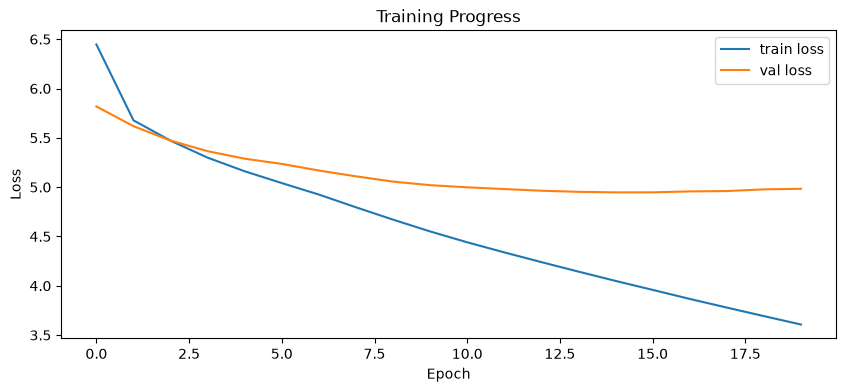

In [10]:
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Progress")
plt.show()

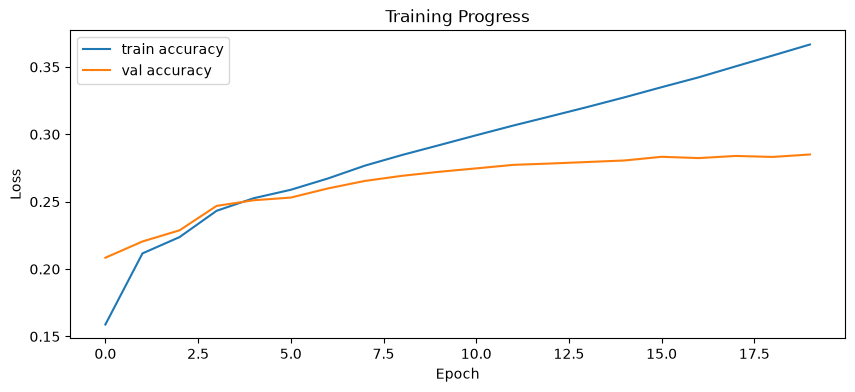

In [11]:
plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Progress")
plt.show()

In [12]:
import pickle
 
with open("eng_tokenizer.pkl", "wb") as f:
    pickle.dump(eng_tokenizer, f)
 
with open("hin_tokenizer.pkl", "wb") as f:
    pickle.dump(hin_tokenizer, f)
 
print("Saved eng_tokenizer.pkl and hin_tokenizer.pkl")
 

Saved eng_tokenizer.pkl and hin_tokenizer.pkl


In [ ]:
"""
Test script for the English -> Hindi seq2seq LSTM translator.

Requires, in the same folder:
  - best_translation_model.keras   (your trained model)
  - eng_tokenizer.pkl
  - hin_tokenizer.pkl

Run:
  python test_translator.py
"""

import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Must match the values used during training ---
MAX_ENG_LEN = 18
MAX_HIN_LEN = 18
LSTM_UNITS = 128

MODEL_PATH = "best_translations_model.keras"
ENG_TOKENIZER_PATH = "eng_tokenizer.pkl"
HIN_TOKENIZER_PATH = "hin_tokenizer.pkl"


def load_assets():
    trained_model = load_model(MODEL_PATH)

    with open(ENG_TOKENIZER_PATH, "rb") as f:
        eng_tokenizer = pickle.load(f)
    with open(HIN_TOKENIZER_PATH, "rb") as f:
        hin_tokenizer = pickle.load(f)

    return trained_model, eng_tokenizer, hin_tokenizer


def build_inference_models(trained_model):
    """
    Rebuilds encoder + step-by-step decoder models using the SAME trained
    layers (so weights are reused, no retraining needed).
    """
    # --- Encoder inference model ---
    # Pull tensors directly off the already-built graph (don't reconstruct
    # from a bare layer's `.input`/`.output` — unreliable across Keras versions).
    encoder_inputs = trained_model.input[0]  # the "Encoder_Input" tensor
    _, state_h, state_c = trained_model.get_layer("Encoder_LSTM").output
    encoder_model = Model(encoder_inputs, [state_h, state_c])

    # --- Decoder inference model (runs one token at a time) ---
    decoder_embedding_layer = trained_model.get_layer("Decoder_Embedding")
    decoder_lstm = trained_model.get_layer("Decoder_LSTM")
    decoder_dense = trained_model.get_layer("Output_Layer")

    decoder_state_input_h = Input(shape=(LSTM_UNITS,), name="decoder_state_input_h")
    decoder_state_input_c = Input(shape=(LSTM_UNITS,), name="decoder_state_input_c")
    decoder_single_input = Input(shape=(1,), name="decoder_single_input")

    dec_emb2 = decoder_embedding_layer(decoder_single_input)
    decoder_outputs2, state_h2, state_c2 = decoder_lstm(
        dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c]
    )
    decoder_outputs2 = decoder_dense(decoder_outputs2)

    decoder_model = Model(
        [decoder_single_input, decoder_state_input_h, decoder_state_input_c],
        [decoder_outputs2, state_h2, state_c2],
    )

    return encoder_model, decoder_model


def translate(sentence, encoder_model, decoder_model, eng_tokenizer, hin_tokenizer):
    sentence = sentence.lower().strip()
    seq = eng_tokenizer.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=MAX_ENG_LEN, padding="post", truncating="post")

    states_value = encoder_model.predict(seq, verbose=0)

    start_token = hin_tokenizer.word_index.get("<start>")
    end_token = hin_tokenizer.word_index.get("<end>")

    target_seq = np.array([[start_token]])

    decoded_words = []
    for _ in range(MAX_HIN_LEN):
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = hin_tokenizer.index_word.get(sampled_token_index, "<unk>")

        if sampled_word == "<end>" or sampled_token_index == 0:
            break

        decoded_words.append(sampled_word)

        target_seq = np.array([[sampled_token_index]])
        states_value = [h, c]

    return " ".join(decoded_words)


def main():
    trained_model, eng_tokenizer, hin_tokenizer = load_assets()
    encoder_model, decoder_model = build_inference_models(trained_model)

    test_sentences = [
        "how are you",
        "i am fine",
        "good morning",
        "what is your name",
        "the weather is nice today",
    ]

    print("Testing translations:\n")
    for s in test_sentences:
        translation = translate(s, encoder_model, decoder_model, eng_tokenizer, hin_tokenizer)
        print(f"EN: {s}")
        print(f"HI: {translation}\n")

    # Interactive mode
    print("Type a sentence to translate (or 'quit' to exit):")
    while True:
        user_input = input("> ").strip()
        if user_input.lower() in ("quit", "exit"):
            break
        print(translate(user_input, encoder_model, decoder_model, eng_tokenizer, hin_tokenizer))


if __name__ == "__main__":
    main()

Testing translations:

EN: how are you
HI: क्या क्या है कि

EN: i am fine
HI: मैं क्या

EN: good morning
HI: बाहरी कड़ियाँ

EN: what is your name
HI: क्या क्या नहीं है

EN: the weather is nice today
HI: विवेकानन्द की धन्यवाद

Type a sentence to translate (or 'quit' to exit):
